In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import colors as mcolors

Index(['Reporting Period', 'Project ID', 'Project County', 'Project City',
       'Project ZIP', 'Gas Utility', 'Electric Utility',
       'Project Completion Date', 'Total Project Cost',
       'Pre-Retrofit Home Heating Fuel Type', 'Year Home Built',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'Year_Home_built_missing_flag', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude'],
      dtype='object')


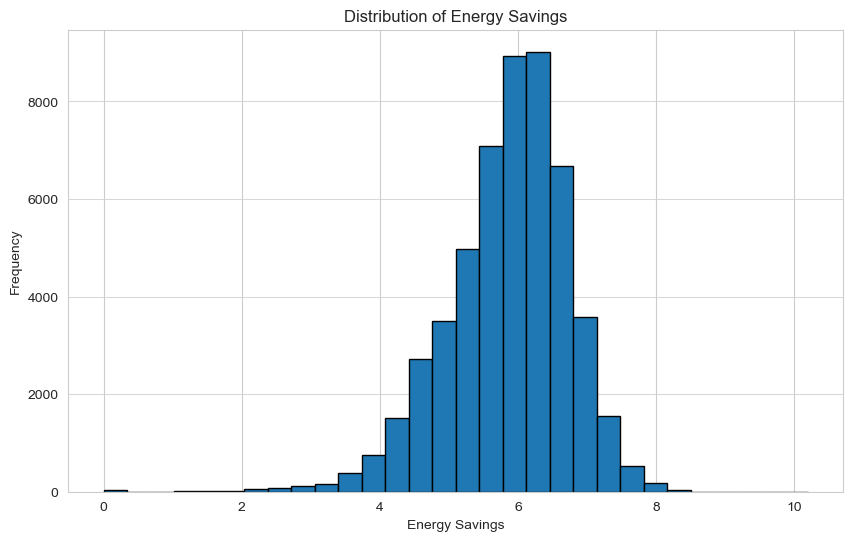

In [11]:
# Part 1: Data Loading and Initial Exploration
df = pd.read_csv('..\\Datasets\\Preprocessed_dataset.csv', low_memory=False)

print(df.columns)

# Plotting the distribution of the target variable 'Energy_Savings'
plt.figure(figsize=(10, 6))
plt.hist(df['First Year Modeled Project Energy Savings $ Estimate'], bins=30, edgecolor='k')
plt.title('Distribution of Energy Savings')
plt.xlabel('Energy Savings')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


Detected columns:
{'building_type_col': 'Type Of Dwelling', 'year_built_col': 'Year Home Built', 'heating_system_col': 'Pre-Retrofit Home Heating Fuel Type', 'target_col': 'First Year Modeled Project Energy Savings $ Estimate'}


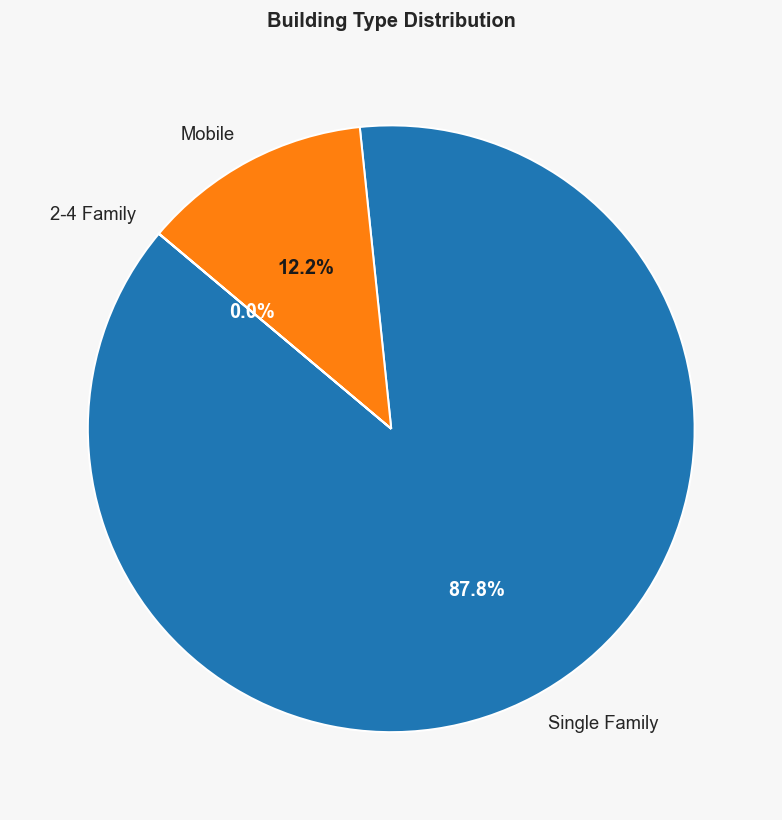

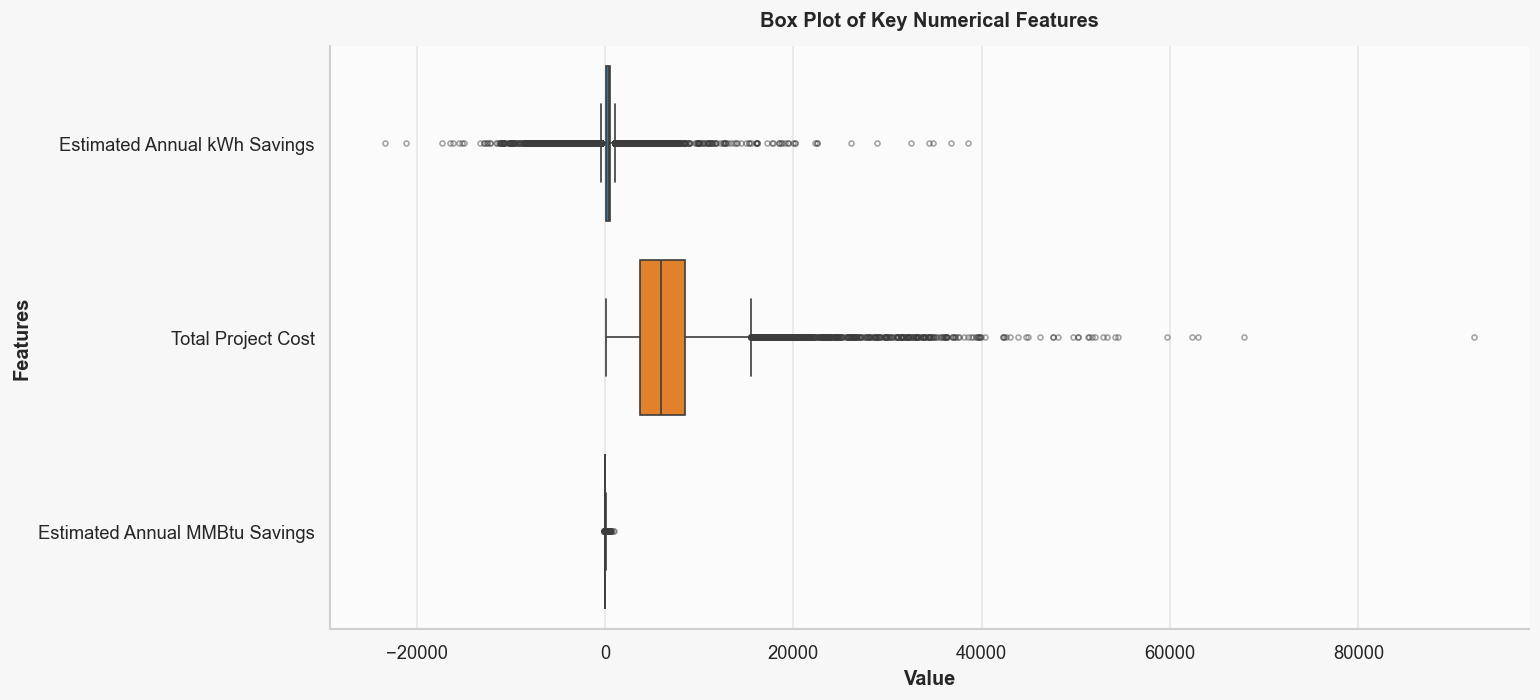

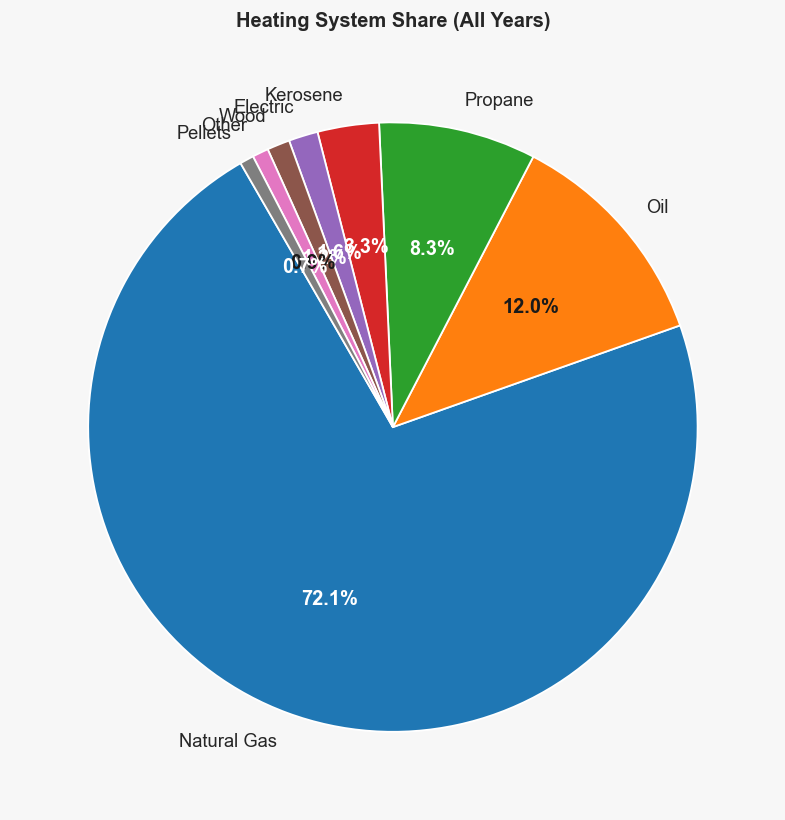

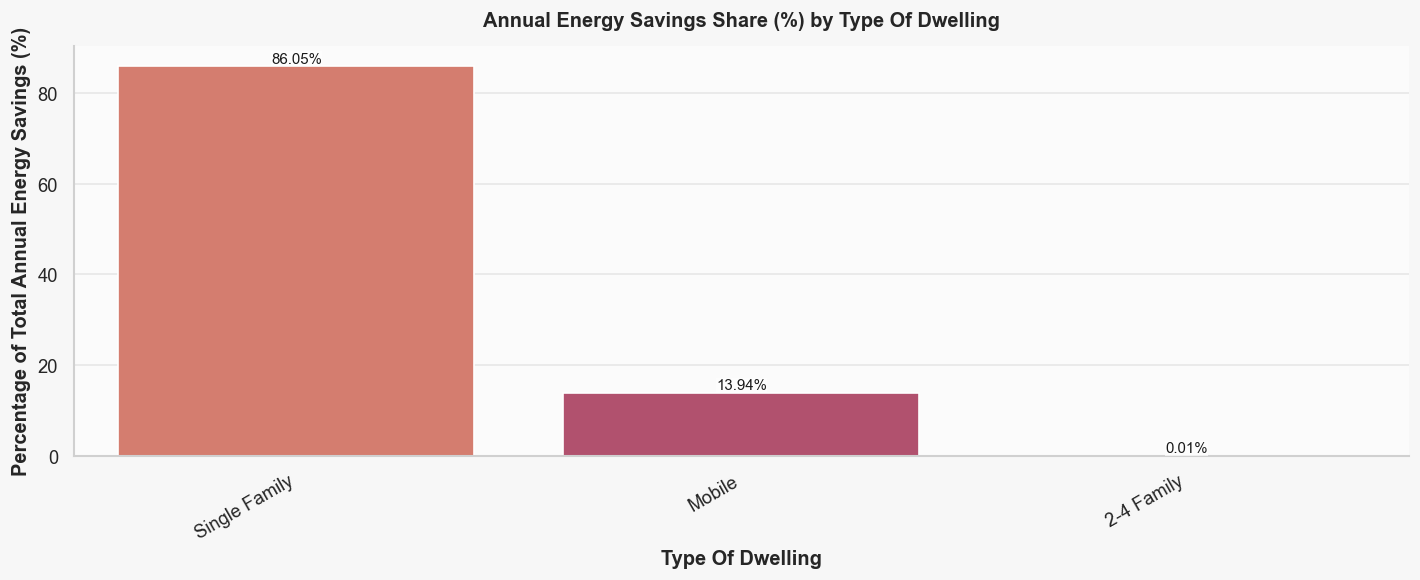

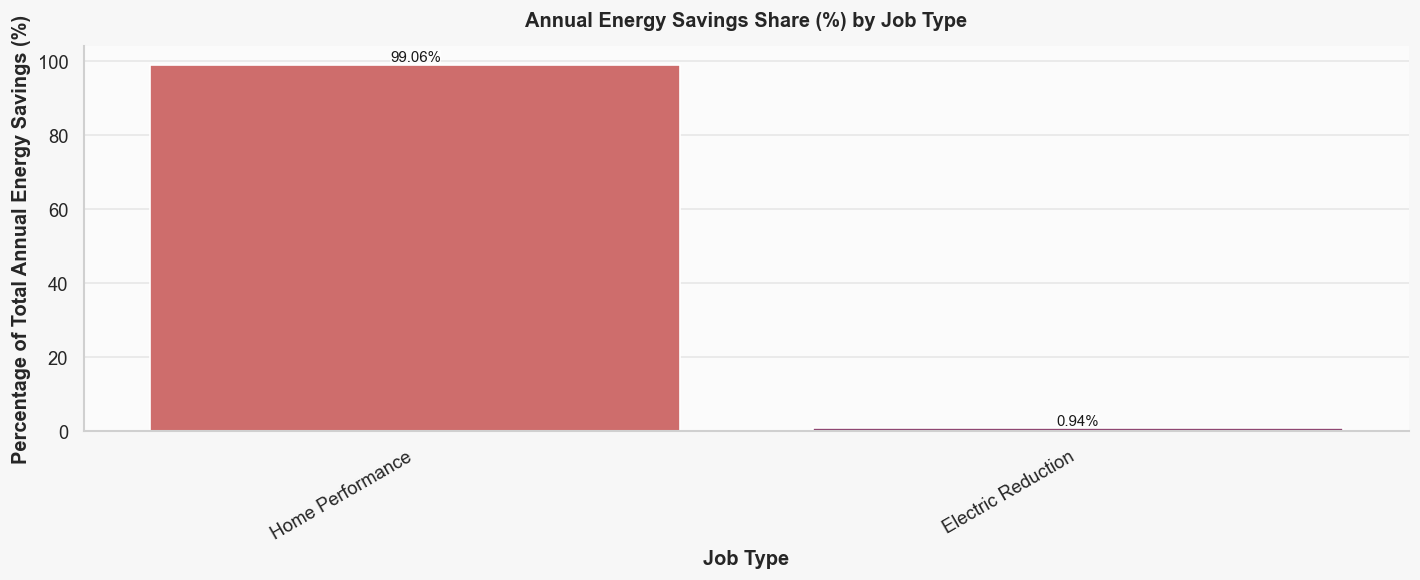

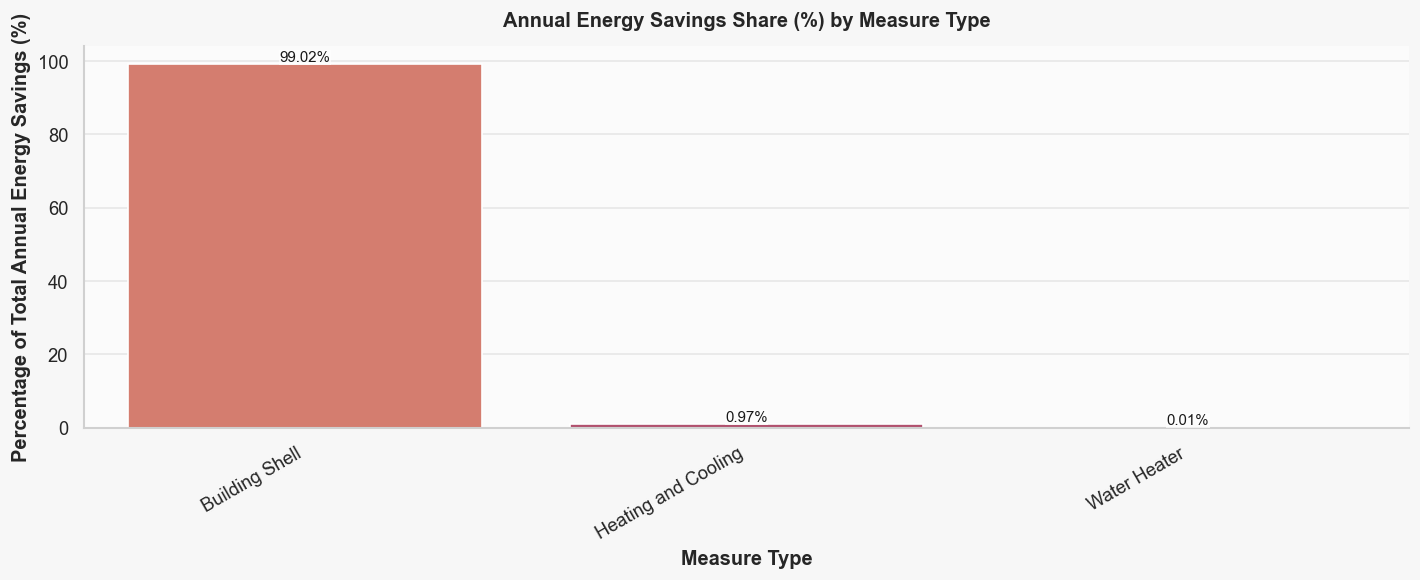

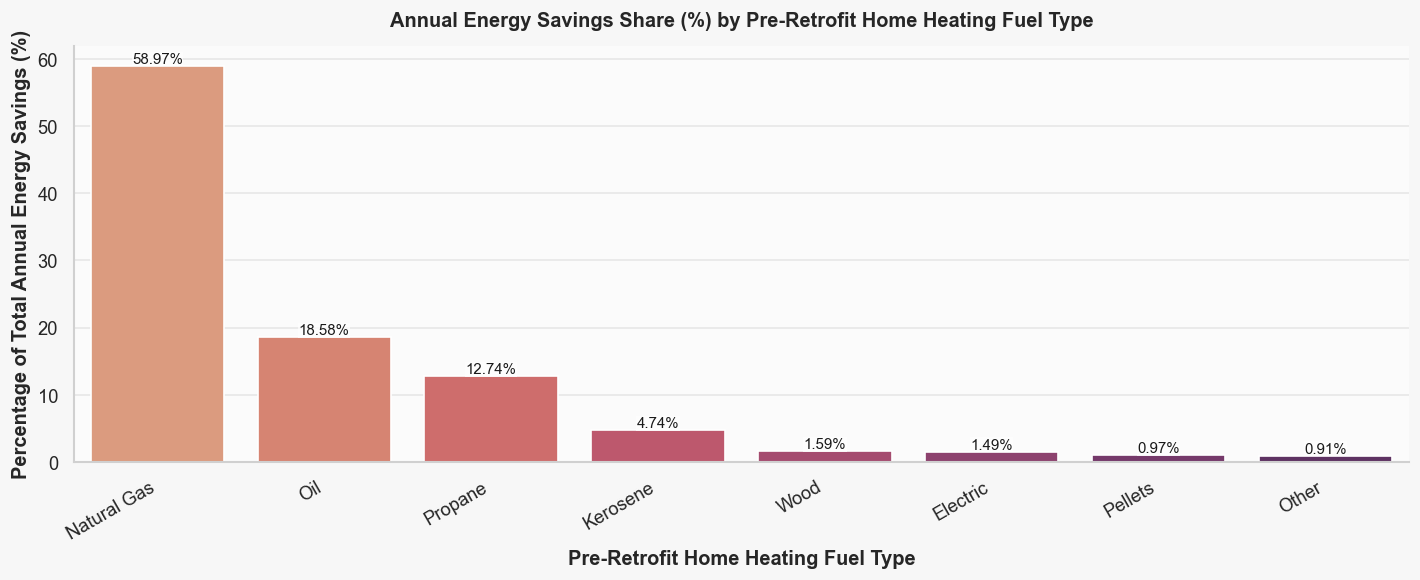

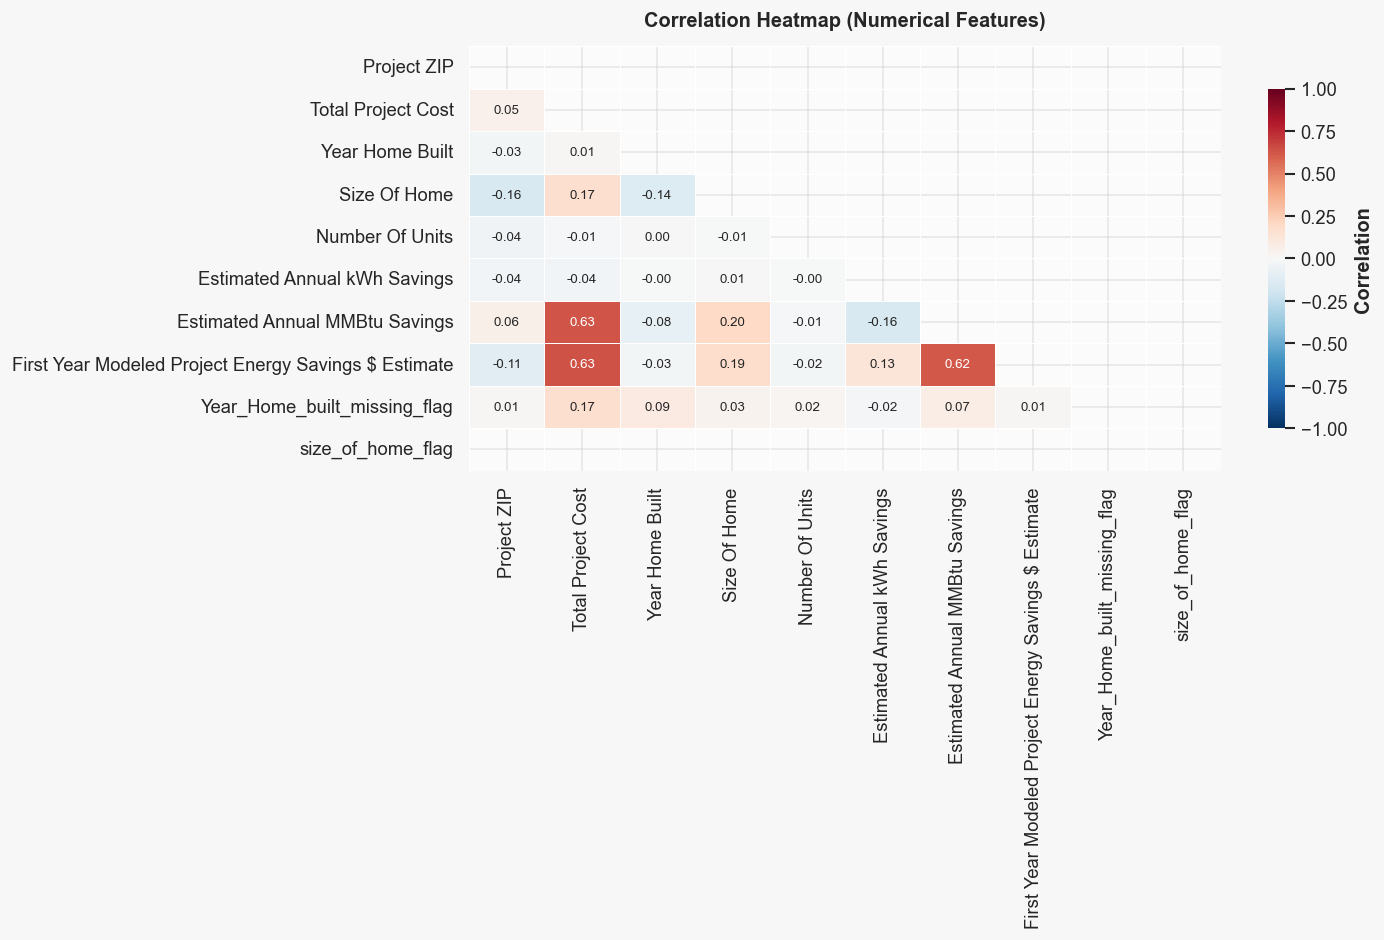

In [15]:
# Part 2: Visualization of Features
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.facecolor'] = '#f7f7f7'
plt.rcParams['axes.facecolor'] = '#fbfbfb'
plt.rcParams['axes.edgecolor'] = '#d9d9d9'
plt.rcParams['grid.color'] = '#d0d0d0'
plt.rcParams['grid.alpha'] = 0.45
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'semibold'

target_col = 'First Year Modeled Project Energy Savings $ Estimate'

# Robust column matching for this dataset (with keyword fallback)
def find_col_by_candidates(df, candidates):
    lower_to_original = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_to_original:
            return lower_to_original[cand.lower()]
    return None

def find_col_by_keywords(df, keyword_groups):
    for col in df.columns:
        lc = col.lower()
        for group in keyword_groups:
            if all(k in lc for k in group):
                return col
    return None

def set_autotext_contrast(wedges, autotexts):
    for w, t in zip(wedges, autotexts):
        r, g, b, _ = w.get_facecolor()
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        t.set_color('white' if luminance < 0.5 else '#1a1a1a')
        t.set_fontweight('bold')

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#d0d0d0')
    ax.spines['bottom'].set_color('#d0d0d0')

def annotate_bars(ax, value_format='{:.2f}%'):
    for patch in ax.patches:
        h = patch.get_height()
        if pd.notna(h):
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                h,
                value_format.format(h),
                ha='center',
                va='bottom',
                fontsize=9,
                color='#1a1a1a',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.25)
            )

def transformed_to_original(series):
    s = pd.to_numeric(series, errors='coerce')
    # In this dataset the target appears log-transformed; expm1 reverts log1p safely.
    restored = np.expm1(s)
    if np.isinf(restored).any():
        restored = np.exp(s)
    return pd.Series(restored, index=series.index)

building_type_col = find_col_by_candidates(df, ['Type Of Dwelling', 'Building Type', 'Property Type'])
if building_type_col is None:
    building_type_col = find_col_by_keywords(df, [['dwelling', 'type'], ['building', 'type'], ['property', 'type']])

year_built_col = find_col_by_candidates(df, ['Year Home Built', 'Year Built'])
if year_built_col is None:
    year_built_col = find_col_by_keywords(df, [['year', 'built']])

heating_system_col = find_col_by_candidates(df, ['Pre-Retrofit Home Heating Fuel Type', 'Heating System', 'Heating Fuel Type'])
if heating_system_col is None:
    heating_system_col = find_col_by_keywords(df, [['heating'], ['fuel', 'type']])

print('Detected columns:')
print({
    'building_type_col': building_type_col,
    'year_built_col': year_built_col,
    'heating_system_col': heating_system_col,
    'target_col': target_col
})

# -----------------------------
# Univariate Analysis
# -----------------------------

# 1) Building type distribution (Pie only, blue/orange palette)
if building_type_col is not None:
    bt_counts = df[building_type_col].fillna('Missing').value_counts().head(10)
    base_colors = ['#1f77b4', '#ff7f0e']
    pie_colors = [base_colors[i % len(base_colors)] for i in range(len(bt_counts))]

    plt.figure(figsize=(10, 7), dpi=120)
    wedges, texts, autotexts = plt.pie(
        bt_counts.values,
        labels=bt_counts.index.astype(str),
        colors=pie_colors,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
    )
    set_autotext_contrast(wedges, autotexts)
    plt.title('Building Type Distribution', pad=14)
    plt.tight_layout()
    plt.show()
else:
    print('Building type column not found. Skipping pie chart.')

# 2) Box plot for key numerical columns only
important_cols = [
    'Estimated Annual kWh Savings',
    'Total Project Cost',
    'Estimated Annual MMBtu Savings'
]
available_important_cols = [c for c in important_cols if c in df.columns]

if available_important_cols:
    plot_df = df[available_important_cols].apply(pd.to_numeric, errors='coerce')
    plt.figure(figsize=(13, 6), dpi=120)
    ax = sns.boxplot(
        data=plot_df,
        orient='h',
        palette=['#1f77b4', '#ff7f0e', '#2ca02c'][:len(available_important_cols)],
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.45}
    )
    ax.set_title('Box Plot of Key Numerical Features', pad=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Features')
    style_axes(ax)
    plt.tight_layout()
    plt.show()
else:
    print('Important columns for box plot not found.')

# -----------------------------
# Bivariate Analysis
# -----------------------------

# Heating system distribution across all years (Pie chart)
if heating_system_col is not None:
    heat_counts = df[heating_system_col].fillna('Missing').value_counts().head(8)
    heat_colors = sns.color_palette('tab10', n_colors=len(heat_counts))

    plt.figure(figsize=(9, 7), dpi=120)
    wedges, texts, autotexts = plt.pie(
        heat_counts.values,
        labels=heat_counts.index.astype(str),
        colors=heat_colors,
        autopct='%1.1f%%',
        startangle=120,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.1}
    )
    set_autotext_contrast(wedges, autotexts)
    plt.title('Heating System Share (All Years)', pad=12)
    plt.tight_layout()
    plt.show()
else:
    print('Heating system column not found. Skipping heating system pie chart.')

# -----------------------------
# Target Distribution by Category (Percent)
# -----------------------------

# Convert transformed target back to original scale and show percentage contribution by category
if target_col in df.columns:
    temp_target = df.copy()
    temp_target[target_col] = transformed_to_original(temp_target[target_col])
    temp_target = temp_target.dropna(subset=[target_col])
    temp_target = temp_target[temp_target[target_col] >= 0]

    compare_features = [
        c for c in [building_type_col, 'Job Type', 'Measure Type', heating_system_col]
        if c is not None and c in temp_target.columns
    ]

    for feat in compare_features:
        top_levels = temp_target[feat].fillna('Missing').value_counts().head(8).index
        chart_df = temp_target[temp_target[feat].fillna('Missing').isin(top_levels)].copy()
        chart_df[feat] = chart_df[feat].fillna('Missing')

        sum_df = (
            chart_df.groupby(feat, as_index=False)[target_col]
            .sum()
            .sort_values(target_col, ascending=False)
        )
        total_val = sum_df[target_col].sum()
        if total_val > 0:
            sum_df['percent_of_total'] = 100 * sum_df[target_col] / total_val
        else:
            sum_df['percent_of_total'] = 0.0

        plt.figure(figsize=(12, 5), dpi=120)
        ax = sns.barplot(
            data=sum_df,
            x=feat,
            y='percent_of_total',
            hue=feat,
            palette=sns.color_palette('flare', n_colors=sum_df.shape[0]),
            edgecolor='white',
            legend=False
        )
        ax.set_title(f'Annual Energy Savings Share (%) by {feat}', pad=12)
        ax.set_xlabel(feat)
        ax.set_ylabel('Percentage of Total Annual Energy Savings (%)')
        plt.xticks(rotation=30, ha='right')
        annotate_bars(ax, value_format='{:.2f}%')
        style_axes(ax)
        plt.tight_layout()
        plt.show()

# -----------------------------
# Multivariate Analysis
# -----------------------------

# Correlation heatmap on numerical data with annotated values
corr_df = df.select_dtypes(include=[np.number]).copy()
if target_col in df.columns and target_col not in corr_df.columns:
    corr_df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

if corr_df.shape[1] >= 2:
    corr = corr_df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(12, 8), dpi=120)
    ax = sns.heatmap(
        corr,
        mask=mask,
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor='white',
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
    )
    ax.set_title('Correlation Heatmap (Numerical Features)', pad=12)
    style_axes(ax)
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for correlation heatmap.')

In [ ]:
# Part 3: VIF Analysis and ANOVA Tests for Feature Groups
from scipy.stats import f_oneway, levene, kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

target_col = 'First Year Modeled Project Energy Savings $ Estimate'

# 1) VIF Analysis (numeric predictors)
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Exclude obvious identifiers/flags and target from VIF inputs
exclude_keywords = ['id', 'zip', 'latitude', 'longitude', 'flag']
vif_features = [
    c for c in numeric_df.columns
    if c != target_col and not any(k in c.lower() for k in exclude_keywords)
]

if len(vif_features) >= 2:
    X = numeric_df[vif_features].copy()
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median(numeric_only=True))

    # Drop near-constant columns for stable VIF estimates
    nunique = X.nunique(dropna=False)
    X = X.loc[:, nunique > 1]

    if X.shape[1] >= 2:
        X_with_const = sm.add_constant(X, has_constant='add')
        vif_rows = []
        for i, col in enumerate(X_with_const.columns):
            if col == 'const':
                continue
            vif_val = variance_inflation_factor(X_with_const.values, i)
            vif_rows.append({'feature': col, 'VIF': vif_val})

        vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)
        vif_df['risk_flag'] = np.where(vif_df['VIF'] > 10, 'High', np.where(vif_df['VIF'] > 5, 'Moderate', 'Low'))

        print('VIF Results (higher means stronger multicollinearity):')
        display(vif_df)
    else:
        print('Not enough variable numeric columns after filtering for VIF.')
else:
    print('Not enough numeric predictors found for VIF analysis.')

# -----------------------------
# 2) One-way ANOVA for key categorical groups
# -----------------------------
candidate_group_features = [
    'Type Of Dwelling',
    'Job Type',
    'Measure Type',
    'Pre-Retrofit Home Heating Fuel Type',
    'Project County'
]
group_features = [c for c in candidate_group_features if c in df.columns]

anova_results = []

for feat in group_features:
    temp = df[[feat, target_col]].copy()
    temp[target_col] = pd.to_numeric(temp[target_col], errors='coerce')
    temp[feat] = temp[feat].fillna('Missing').astype(str)
    temp = temp.dropna(subset=[target_col])

    # Keep meaningful groups only
    counts = temp[feat].value_counts()
    valid_levels = counts[counts >= 30].index
    temp = temp[temp[feat].isin(valid_levels)]

    # Limit to top levels for stable comparison and readability
    top_levels = temp[feat].value_counts().head(10).index
    temp = temp[temp[feat].isin(top_levels)]

    grouped = [grp[target_col].values for _, grp in temp.groupby(feat)]
    level_names = list(temp.groupby(feat).groups.keys())

    if len(grouped) < 2:
        continue

    # Classical ANOVA
    f_stat, p_val = f_oneway(*grouped)

    # Variance homogeneity check (assumption for ANOVA)
    lev_stat, lev_p = levene(*grouped, center='median')

    # Robust non-parametric alternative
    kw_stat, kw_p = kruskal(*grouped)

    # Effect size: eta squared
    grand_mean = temp[target_col].mean()
    ss_between = 0.0
    for level in level_names:
        vals = temp.loc[temp[feat] == level, target_col]
        ss_between += len(vals) * (vals.mean() - grand_mean) ** 2
    ss_total = ((temp[target_col] - grand_mean) ** 2).sum()
    eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

    anova_results.append({
        'feature_group': feat,
        'n_rows': len(temp),
        'n_levels_used': len(level_names),
        'anova_F': f_stat,
        'anova_p': p_val,
        'levene_p': lev_p,
        'kruskal_H': kw_stat,
        'kruskal_p': kw_p,
        'eta_squared': eta_sq
    })

if anova_results:
    anova_df = pd.DataFrame(anova_results).sort_values('anova_p')
    anova_df['anova_significant_5pct'] = anova_df['anova_p'] < 0.05
    anova_df['kruskal_significant_5pct'] = anova_df['kruskal_p'] < 0.05

    print('ANOVA + Assumption/Robustness Results by Feature Group:')
    display(anova_df)
else:
    print('No valid feature groups found for ANOVA under current filtering rules.')

# -----------------------------
# 3) Suggested next tests for this dataset
# -----------------------------
suggested_tests = pd.DataFrame({
    'recommended_test': [
        'Breusch-Pagan test (heteroscedasticity)',
        'Ramsey RESET test (model specification)',
        'Permutation ANOVA / randomization test',
        'Welch ANOVA (unequal variances)',
        'Two-part or hurdle model (many near-zero savings)',
        'Spatial autocorrelation (Moran\'s I) using latitude/longitude',
        'Influence diagnostics (Cook\'s distance, leverage)',
        'Robust regression (Huber / Quantile regression)'
    ],
    'why_it_matters_here': [
        'Project costs and savings likely have non-constant variance.',
        'Checks whether linear model form is missing nonlinear terms/interactions.',
        'Useful when ANOVA assumptions are questionable in highly imbalanced groups.',
        'Better for group comparisons when Levene test indicates variance differences.',
        'Energy savings distributions often have zero-inflation and heavy skew.',
        'County/location effects may introduce geographic clustering in outcomes.',
        'Large-cost retrofit outliers can dominate ordinary least squares estimates.',
        'Provides stable estimates under skew and outliers in savings/cost data.'
    ]
})

print('Recommended Additional Statistical Tests:')
display(suggested_tests)

VIF Results (higher means stronger multicollinearity):


,feature,VIF,risk_flag
0,Estimated Annual MMBtu Savings,1.758231,Low
1,Total Project Cost,1.689284,Low
2,Size Of Home,1.065214,Low
3,Estimated Annual kWh Savings,1.035680,Low
4,Year Home Built,1.030523,Low
5,Number Of Units,1.000240,Low


ANOVA + Assumption/Robustness Results by Feature Group:


,feature_group,n_rows,n_levels_used,anova_F,anova_p,levene_p,kruskal_H,kruskal_p,eta_squared,anova_significant_5pct,kruskal_significant_5pct
1,Job Type,51930,2,4753.311645,0.000000e+00,1.592822e-83,3776.860878,0.000000e+00,0.083860,True,True
3,Pre-Retrofit Home Heating Fuel Type,51930,9,718.612884,0.000000e+00,4.670982e-34,5961.927649,0.000000e+00,0.099686,True,True
4,Project County,31754,10,465.563865,0.000000e+00,3.998355e-71,4292.249051,0.000000e+00,0.116604,True,True
0,Type Of Dwelling,51925,2,318.913067,4.081241e-71,7.097712e-26,346.105693,2.986714e-77,0.006105,True,True
2,Measure Type,51925,2,2.892736,8.898572e-02,9.326017e-02,1.975256,1.598910e-01,0.000056,False,False


Recommended Additional Statistical Tests:


,recommended_test,why_it_matters_here
0,Breusch-Pagan test (heteroscedasticity),Project costs and savings likely have non-cons...
1,Ramsey RESET test (model specification),Checks whether linear model form is missing no...
2,Permutation ANOVA / randomization test,Useful when ANOVA assumptions are questionable...
3,Welch ANOVA (unequal variances),Better for group comparisons when Levene test ...
4,Two-part or hurdle model (many near-zero savings),Energy savings distributions often have zero-i...
5,Spatial autocorrelation (Moran's I) using lati...,County/location effects may introduce geograph...
6,"Influence diagnostics (Cook's distance, leverage)",Large-cost retrofit outliers can dominate ordi...
7,Robust regression (Huber / Quantile regression),Provides stable estimates under skew and outli...
